# Import 

In [84]:


import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm 
import math
import torch.nn.functional as F
from scipy.integrate import solve_ivp
import xarray as xr
import torch.optim as optim
torch.set_num_threads(20)
import torch
import torch.nn as nn
import torch.optim as optim
import itertools
import numpy as np
import matplotlib.pyplot as plt
import torch
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement
import re
import pandas as pd
%load_ext autoreload
%autoreload 2

from scipy.ndimage import uniform_filter1d

path = "/home/kuoray/Master/proj2_diffusion/ENSO/WWB /wwb and entropy/final_version/data/"
fig_path = "/home/kuoray/Master/proj2_diffusion/ENSO/WWB /wwb and entropy/final_version/figs/"
data_labels = ['RMM1','RMM2','BOX_1','BOX_2','BOX_3','BOX_4']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
def normalize_array(a): 
    # Shape: (t,x) 
    return ( a-a.mean(axis=0) )/a.std(axis=0) 

In [86]:
ds_dynamical_system = xr.open_dataset(path+'data_dynamical_system_1102.nc')
time_daily = ds_dynamical_system['valid_time']
ds_dynamical_system

<xarray.Dataset> Size: 4MB
Dimensions:                       (validtime: 15341, dim_x: 6, valid_time: 15341)
Coordinates:
    number                        (valid_time) int64 123kB ...
  * valid_time                    (valid_time) datetime64[ns] 123kB 1979-01-0...
    dayofyear                     (valid_time) int64 123kB ...
Dimensions without coordinates: validtime, dim_x
Data variables:
    default_no_xro                (validtime, dim_x) float64 736kB ...
    modified_no_xro               (validtime, dim_x) float64 736kB ...
    default_with_xro              (validtime, dim_x) float64 736kB ...
    modified_with_xro             (validtime, dim_x) float64 736kB ...
    default_no_xro_remove_linear  (validtime, dim_x) float64 736kB ...
Attributes:
    description:  Calculated from 1102 tidyup running var and sst different b...

In [87]:
# Xro monthly
ds_monthly_xro = xr.open_dataset(path+"monthly_xro.nc")
Nino_monthly_xr = ds_monthly_xro['Nino34']
IOD_monthly_xr = ds_monthly_xro['IOD']
monthly_xro_np = np.zeros( (len(ds_monthly_xro['time'][:]), 10)   )


xro_labels = [key for i,key in enumerate(ds_monthly_xro.keys())]
time_monthly = ds_monthly_xro['time'][:]
# XRO nearest 

#xro_nearest = np.zeros((len(time_daily),10))
#ds_xro_nearest = xr.open_dataset(path+"daily_xro_nearest.nc")
for i,key in enumerate(ds_monthly_xro.keys()): 
#    xro_nearest[:,i] = ds_xro_nearest[key]
    monthly_xro_np[:,i]   = ds_monthly_xro[key]  
print(monthly_xro_np[:,i].shape)


(504,)


In [88]:
data_dynamical_system        = ds_dynamical_system["default_with_xro"].to_numpy()

In [89]:
import numpy as np
from scipy.spatial import cKDTree

def expansion_logdet_simple_gemeni(delta0, delta1, eps=1e-12):
    """
    delta0, delta1: (k, d) deviations (must be centered!)
    returns log|det J| where J is the LS tangent-map estimate.
    """
    X0 = delta0
    X1 = delta1

    # 計算 A 的條件數 (保留你原本回傳 cond 的需求)
    A = X0.T @ X0
    cond_A = np.linalg.cond(A)

    # 改用 lstsq 取代直接求反矩陣，數值上更穩定 (處理 A 接近奇異矩陣的情況)
    # lstsq 求解 B，使得 X0 @ B \approx X1
    B, residuals, rank, s_lstsq = np.linalg.lstsq(X0, X1, rcond=None)
    J = B.T
    
    # 透過 SVD 計算 log|det J|
    s = np.linalg.svd(J, compute_uv=False)
    s = np.clip(s, eps, None)
    logdet = float(np.sum(np.log(s)))
    
    return logdet, cond_A  # log|det J|

def calc_def_rate_simple_gemeni(data, k, dt=1.0, theiler_window=10,shift=7):
    """
    data: (T, d) time series
    returns: (T-1,) deformation rate = (1/dt)*log|det J_t|
    theiler_window : remove those too close in time dimension 
    shift : X_{t+shift} vs X_t 
    """
    X = np.asarray(data)
    T, d = X.shape
    if T < 3:
        raise ValueError("Need at least 3 time steps.")
    if k >= T-shift:
        raise ValueError("k too large relative to sample size.")

    # 修正陣列長度為 T-1，與 out 對齊
    cond = np.zeros(T-shift) 
    out = np.full(T-shift, np.nan, float)

    #X_t  = X[:-1]   # time t
    #X_tp = X[1:]    # time t+1

    X_t  = X[:-shift]   # time t
    X_tp = X[shift:]    # time t+1
    
    tree = cKDTree(X_t)
    
    # 為了 Theiler window，我們需要多找一些鄰居來篩選
    # 確保不會因為過濾掉時間相近的點而導致鄰居數不足 k
    query_k = min(T - shift, k + 2 * theiler_window + 5)

    for t in range(T-shift):
        # 找尋 query_k 個鄰居
        dists, idx = tree.query(X_t[t], k=query_k)
        
        valid_nn = []
        for i in idx:
            # Theiler Window: 排除自己與時間上太接近的點
            if abs(i - t) > theiler_window:
                valid_nn.append(i)
            # 收集滿 k 個就停止
            if len(valid_nn) == k:
                break
        
        # 萬一資料量太少，過濾後找不到足夠的 k 個點，就退回原本的邏輯 (只排除自己)
        if len(valid_nn) < k:
            valid_nn = [i for i in idx if i != t][:k]
            
        nn = np.array(valid_nn)

        x0 = X_t[t]
        x1 = X_tp[t]

        # IMPORTANT: use deviations (centered)
        #delta0 = X_t[nn] - x0
        #delta1 = X_tp[nn] - x1
        
        delta0 = X_t[nn] - X_t[nn].mean(axis=0)
        delta1 = X_tp[nn] - X_tp[nn].mean(axis=0)

        
        logdet, cond_A = expansion_logdet_simple_gemeni(delta0, delta1)
        
        out[t] = logdet / dt
        cond[t] = cond_A
        
    return out, cond

In [90]:
def robust_clip(a, lo=1, hi=99):
    vmin = np.nanpercentile(a, lo)
    vmax = np.nanpercentile(a, hi)
    return np.clip(a, vmin, vmax), vmin, vmax

# 1 : Lorenz 

In [91]:
from scipy.spatial import cKDTree

In [92]:
# -------------------------
# Lorenz-63 model
# -------------------------
def lorenz63_rhs(x, sigma=10.0, rho=28.0, beta=8/3):
    dx = sigma * (x[1] - x[0])
    dy = x[0] * (rho - x[2]) - x[1]
    dz = x[0] * x[1] - beta * x[2]
    return np.array([dx, dy, dz])


def rk4_step(f, x, dt, **kwargs):
    k1 = f(x, **kwargs)
    k2 = f(x + 0.5*dt*k1, **kwargs)
    k3 = f(x + 0.5*dt*k2, **kwargs)
    k4 = f(x + dt*k3, **kwargs)
    return x + dt*(k1 + 2*k2 + 2*k3 + k4)/6


def integrate_lorenz63(x0, n_steps, dt=0.01, **params):
    traj = np.zeros((n_steps, 3))
    x = np.array(x0, dtype=float)
    
    for i in range(n_steps):
        traj[i] = x
        x = rk4_step(lorenz63_rhs, x, dt, **params)
        
    return traj

In [93]:
# -------------------------
# Lorenz-96 model
# -------------------------
def lorenz96_rhs(x, F=8.0):
    N = len(x)
    dx = np.zeros(N)
    
    for i in range(N):
        dx[i] = (
            (x[(i+1) % N] - x[(i-2) % N]) * x[(i-1) % N]
            - x[i]
            + F
        )
        
    return dx


def integrate_lorenz96(x0, n_steps, dt=0.01, F=8.0):
    N = len(x0)
    traj = np.zeros((n_steps, N))
    x = np.array(x0, dtype=float)
    
    for i in range(n_steps):
        traj[i] = x
        x = rk4_step(lorenz96_rhs, x, dt, F=F)
        
    return traj

In [94]:
traj63 = integrate_lorenz63(
    x0=[1.0, 1.0, 1.0],
    n_steps=20000,
    dt=0.01
)

In [95]:
N = 28
x0 = np.ones(N)
x0[0] += 0.01  # small perturbation

traj96 = integrate_lorenz96(
    x0=x0,
    n_steps=100000,
    dt=0.01,
    F=8.0
)

In [96]:
N = 28
x0 = np.ones(N)
x0[0] += 0.01  # small perturbation

traj96_28 = integrate_lorenz96(
    x0=x0,
    n_steps=100000,
    dt=0.01,
    F=8.0
)

1000


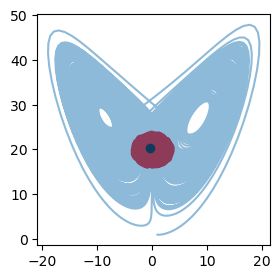

In [97]:
t_total_for_div = 8000
N_scatter = 1000

traj_63_2d = traj63[:,[0,2]] 
tree_63_2d = cKDTree(traj_63_2d)
dists, idx    = tree_63_2d.query([0,20], k=2*N_scatter)
ini_idx = idx[idx<20000-t_total_for_div][:N_scatter]
print(len(ini_idx))
plt.figure(figsize=(3,3))
plt.plot(traj_63_2d[:,0],traj_63_2d[:,1],alpha=0.5)
plt.scatter(traj_63_2d[ini_idx,0],traj_63_2d[ini_idx,1],c='red')
plt.scatter(traj_63_2d[1350,0],traj_63_2d[1350,1],c='black')

In [98]:
np.sort(ini_idx)[0]

1206

In [99]:

div_l63 = np.empty(t_total_for_div) 
for i in range(t_total_for_div-1): 
    x0 = traj_63_2d[ini_idx+i,:]
    x1 = traj_63_2d[ini_idx+i+1,:]
    
    delta0 = x0 - x0.mean(axis=0)
    delta1 = x1 - x1.mean(axis=0)

    logdet, cond_A = expansion_logdet_simple_gemeni(delta0, delta1)
    
    div_l63[i] = logdet / 0.01

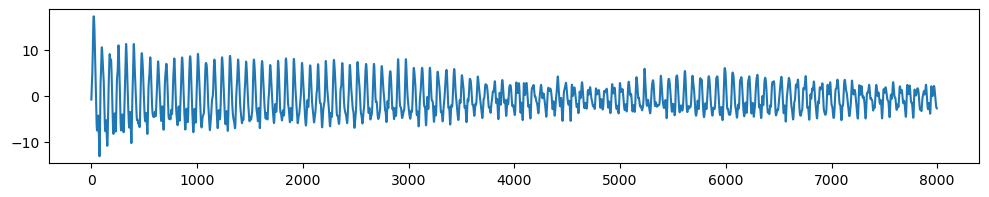

In [100]:
plt.figure(figsize=(12,2))
plt.plot(div_l63[:-3])

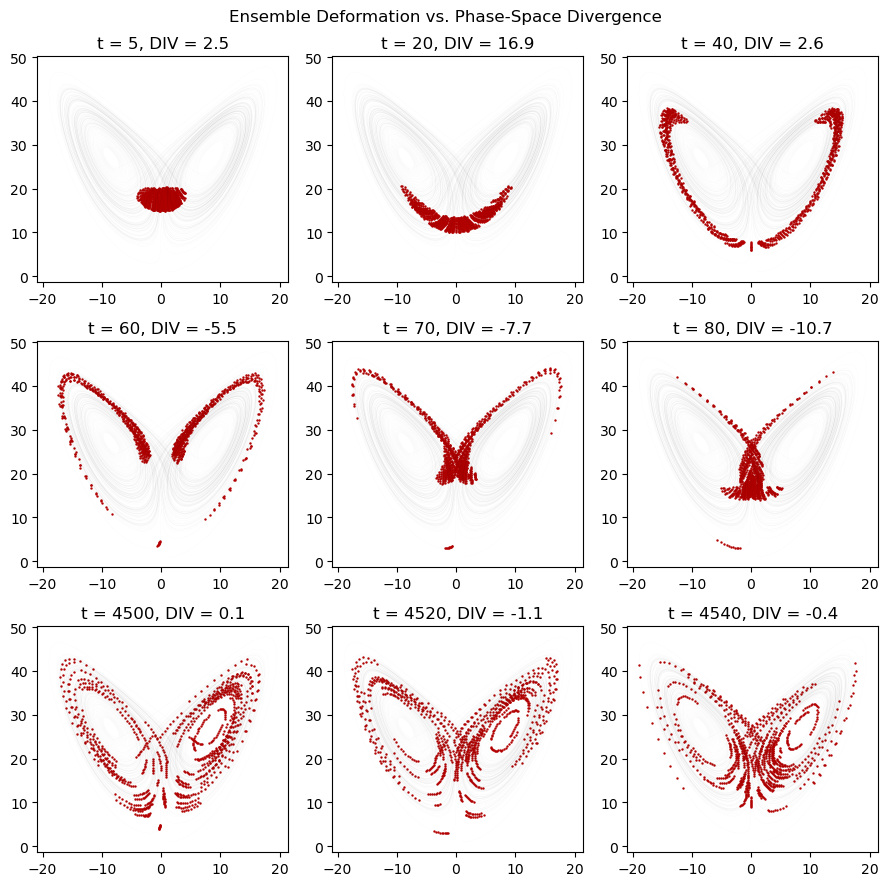

In [101]:
plt.figure(figsize=(9,9))

ttt = [5,20,40,60,70,80,4500,4520,4540]
#ttt = [5,20,40,60,70,80,5500,5520,5540]

for i in range(9): 
    sub_num=(331+i)
    plt.subplot(sub_num)
    plt.plot(traj_63_2d[:,0],traj_63_2d[:,1],color='k',linewidth=0.02,alpha=0.3)

    idx_now_temp = ini_idx +  ttt[i]
    plt.scatter(traj_63_2d[idx_now_temp,0],traj_63_2d[idx_now_temp,1],s=0.5,color=(0.7,0,0))
    plt.title(f't = {ttt[i]}, DIV = {div_l63[ttt[i]]:.1f}')
plt.suptitle('Ensemble Deformation vs. Phase-Space Divergence')
plt.tight_layout()
plt.savefig(fig_path+'1_l63_2d_and_div.png',dpi=300)

In [102]:
def calc_error(ini_idx,data,t_total,method='RMSE',eps=1e-12): 
    """
    RMSE : root mean suare error 
    LOGV : logarithm of ensemble volume defined by cov. matrix 
    """
    error = np.empty(t_total)
    if method == 'RMSE' : 
        for t in range(t_total):
            idx_now  = ini_idx + t
            rmse_now = np.sqrt(np.mean((data[idx_now, :] - data[idx_now, :].mean(axis=0, keepdims=True))**2))
            error[t] = rmse_now 
        return error 
    elif method == 'LOGV' :
        N = len(ini_idx)
        for t in range(t_total):
            X = data[ini_idx + t, :]                 # (N, d)
            D = X - X.mean(axis=0, keepdims=True)    # centered
            C = (D.T @ D) / max(N-1, 1)              # (d, d)
            s = np.linalg.svd(C, compute_uv=False)
            error[t] = 0.5 * np.sum(np.log(np.clip(s, eps, None)))
        return error
    else : 
        raise ValueError("No such method implemented")

In [103]:
# r"Shannon entropy H($\rho_t$)" 
error_method_now = 'LOGV'
ent_l63 = calc_error(ini_idx,traj_63_2d,1500-1,error_method_now)
d_ent_l63 = np.gradient(np.log(ent_l63),0.01)

theorical_l63 = np.zeros(1500)
theorical_l63[0] = ent_l63[0]
for i in range(1000-1):    
    theorical_l63[i+1] = theorical_l63[i] + div_l63[i] - div_l63.mean() 

Text(0.5, 1.0, 'Lorenz63,(x,z) \nPearsonR=0.96')

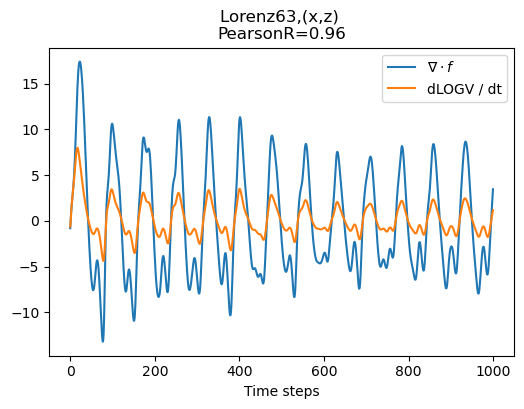

In [104]:
fig, ax = plt.subplots(figsize=(6,4))

from scipy import stats
res = stats.pearsonr(d_ent_l63[:1000], div_l63[:1000])
error_label_str = 'd' + error_method_now + ' / dt'
plt.plot(div_l63[:1000],label=r'$\nabla \cdot f$')
plt.plot(d_ent_l63[:1000], label=error_label_str )
ax.set_xlabel("Time steps")
plt.legend()
plt.title('Lorenz63,(x,z) '+"\n"+f'PearsonR={res[0]:.2f}')

In [105]:
def get_init_idx(t_total_for_div,N_scatter,traj,ini_point):
    t_total_traj = traj.shape[0]    
    tree_traj = cKDTree(traj) 
    dists, idx    = tree_traj.query(ini_point, k=2*N_scatter)
    ini_idx = idx[idx<t_total_traj-t_total_for_div][:N_scatter]
    return ini_idx 

def calc_div_evolution(t_total_for_div,ini_idx,traj,shift,dt):
    div = np.empty(t_total_for_div) 
    for i in range(t_total_for_div-shift): 
        x0 = traj[ini_idx+i,:]
        x1 = traj[ini_idx+i+shift,:]
        
        delta0 = x0 - x0.mean(axis=0)
        delta1 = x1 - x1.mean(axis=0)
    
        logdet, cond_A = expansion_logdet_simple_gemeni(delta0, delta1)
        
        div[i] = logdet / (dt*shift)
    return div     

In [106]:
N_scatter_3d = 1000
ini_idx_l63_3d = get_init_idx(t_total_for_div,N_scatter_3d,traj63,traj63[8000,:])
div_l63_3d     = calc_div_evolution(t_total_for_div,ini_idx_l63_3d,traj63,shift=1,dt=0.01)

In [107]:
ent_l63_3d = calc_error(ini_idx_l63_3d,traj63,1500-1,error_method_now)
d_ent_l63_3d = np.gradient(np.log(ent_l63_3d),0.01)

Text(0.5, 1.0, 'Lorenz63,3d \nPearsonR=0.84')

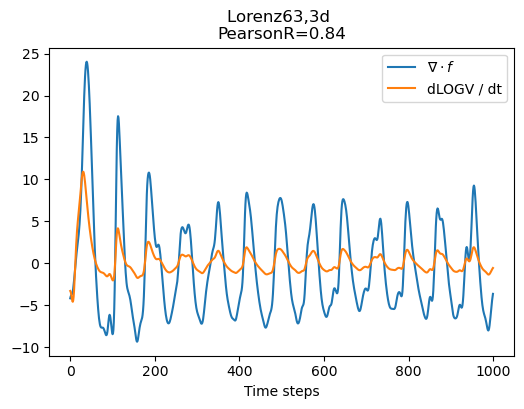

In [108]:
fig, ax = plt.subplots(figsize=(6,4))

from scipy import stats
res = stats.pearsonr(d_ent_l63_3d[:1000], div_l63_3d[:1000])
error_label_str = 'd' + error_method_now + ' / dt'
plt.plot(div_l63_3d[:1000],label=r'$\nabla \cdot f$' )
plt.plot(d_ent_l63_3d[:1000], label=error_label_str)
ax.set_xlabel("Time steps")
plt.legend()
plt.title('Lorenz63,3d '+"\n"+f'PearsonR={res[0]:.2f}')

In [109]:
N_scatter_l96 = 1000
ini_idx_l96 = get_init_idx(t_total_for_div,N_scatter_l96,traj96,traj96[8000,:])
div_l96     = calc_div_evolution(t_total_for_div,ini_idx_l96,traj96,shift=1,dt=0.01)

Text(0.5, 1.0, 'Lorenz96, dim=7 \nPearsonR=1.00')

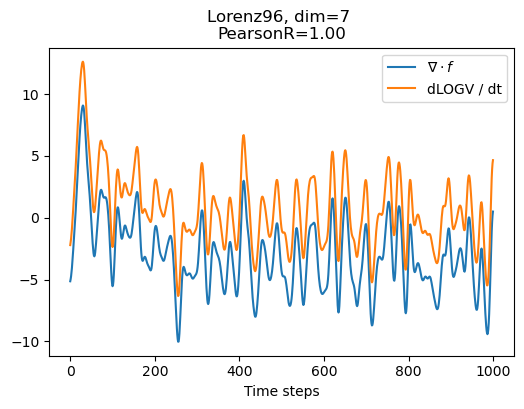

In [110]:
#ent_l96 =  entropy_logdet_cov(ini_idx_l96,traj96,1500-1, eps=1e-12)
ent_l96 = calc_error(ini_idx_l96,traj96,1500-1,error_method_now)
#d_ent_l96 = np.gradient(np.log(ent_l96),0.01)
#log_ent = np.log(ent_l96)
d_ent_l96 = (ent_l96[1:] - ent_l96[:-1]) / 0.01
fig, ax = plt.subplots(figsize=(6,4))

from scipy import stats
res = stats.pearsonr(d_ent_l96[:1000], div_l96[:1000])
error_label_str = 'd' + error_method_now + ' / dt'
plt.plot(div_l96[:1000],label=r'$\nabla \cdot f$' )
plt.plot(d_ent_l96[:1000], label=error_label_str)
ax.set_xlabel("Time steps")
plt.legend()
plt.title('Lorenz96, dim=7 '+"\n"+f'PearsonR={res[0]:.2f}')

In [111]:
N_scatter_l96_28 = 1000
ini_idx_l96_28 = get_init_idx(t_total_for_div,N_scatter_l96_28,traj96_28,traj96_28[10000,:])
div_l96_28     = calc_div_evolution(t_total_for_div,ini_idx_l96_28,traj96_28,shift=1,dt=0.01)

In [112]:
traj96_28.shape

(100000, 28)

Text(0.5, 1.0, 'Lorenz96, dim=7 \nPearsonR=1.00')

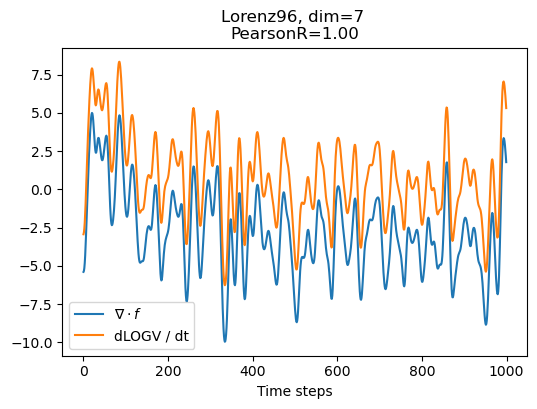

In [113]:
#ent_l96 =  entropy_logdet_cov(ini_idx_l96,traj96,1500-1, eps=1e-12)
ent_l96_28 = calc_error(ini_idx_l96_28,traj96_28,1500-1,error_method_now)
#d_ent_l96 = np.gradient(np.log(ent_l96),0.01)
#log_ent = np.log(ent_l96)
d_ent_l96_28 = (ent_l96_28[1:] - ent_l96_28[:-1]) / 0.01
fig, ax = plt.subplots(figsize=(6,4))

from scipy import stats
res = stats.pearsonr(d_ent_l96_28[:1000], div_l96_28[:1000])
error_label_str = 'd' + error_method_now + ' / dt'
plt.plot(div_l96_28[:1000],label=r'$\nabla \cdot f$' )
plt.plot(d_ent_l96_28[:1000], label=error_label_str)
ax.set_xlabel("Time steps")
plt.legend()
plt.title('Lorenz96, dim=7 '+"\n"+f'PearsonR={res[0]:.2f}')

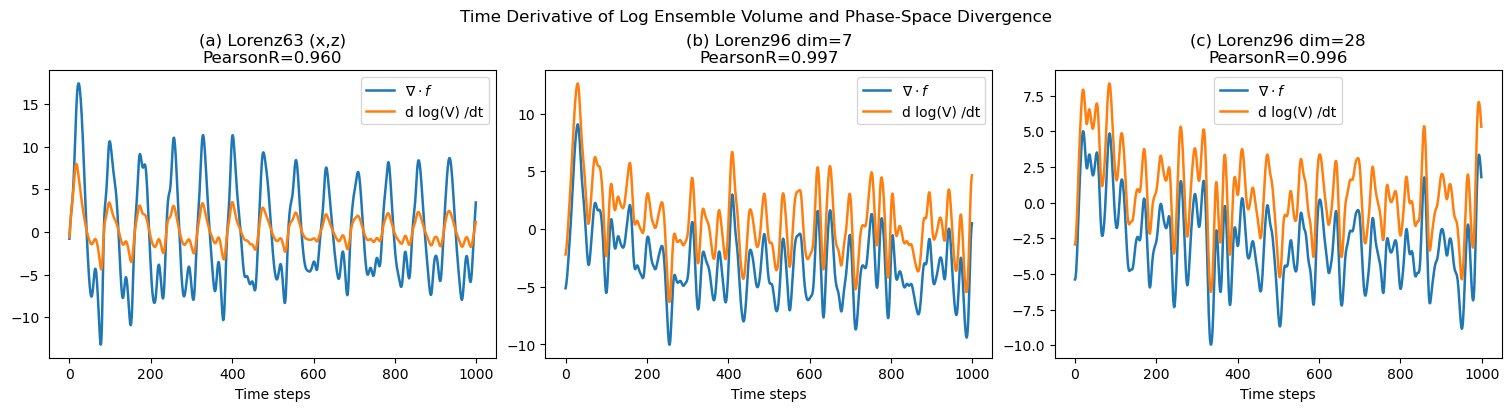

In [114]:
def plot_div_entropy_panel(ax, d_ent, div, title, 
                           tmax=1000, burn=0,
                           dt=1.0):
    """
    ax    : matplotlib axis
    d_ent : d/dt entropy (array)
    div   : divergence array
    title : panel title
    tmax  : how many time steps to show
    burn  : burn-in when computing Pearson R
    dt    : time step (only for label consistency)
    """

    # truncate
    d_ent = d_ent[:tmax]
    div   = div[:tmax]

    # correlation (optionally skip burn-in)
    r, _ = stats.pearsonr(d_ent[burn:], div[burn:])

    ax.plot(div, label=r'$\nabla \cdot f$', lw=1.8)
    ax.plot(d_ent, label='d log(V) /dt', lw=1.8)

    ax.set_xlabel("Time steps")
    ax.set_title(f"{title}\nPearsonR={r:.3f}")
    ax.legend()


# ============================
# Example: 3 panels
# ============================

fig, axs = plt.subplots(1, 3, figsize=(15,4), constrained_layout=True)

plot_div_entropy_panel(
    axs[0], 
    d_ent_l63, 
    div_l63, 
    "(a) Lorenz63 (x,z)"
)

plot_div_entropy_panel(
    axs[1], 
    d_ent_l96, 
    div_l96, 
    "(b) Lorenz96 dim=7"
)

plot_div_entropy_panel(
    axs[2], 
    d_ent_l96_28, 
    div_l96_28, 
    "(c) Lorenz96 dim=28"
)

plt.suptitle('Time Derivative of Log Ensemble Volume and Phase-Space Divergence')
plt.savefig(fig_path+'2_different_system.png',dpi=300)

# 2 : Running variance 

In [115]:
time_tmp = time_daily.to_index()
idx_first_day = np.where(time_tmp.day == 1)[0]
len(idx_first_day)

504

In [116]:
shift_now   = 7
k_now       = 30
div_daily,_ = calc_def_rate_simple_gemeni(data_dynamical_system[:,:],k_now,shift=shift_now )

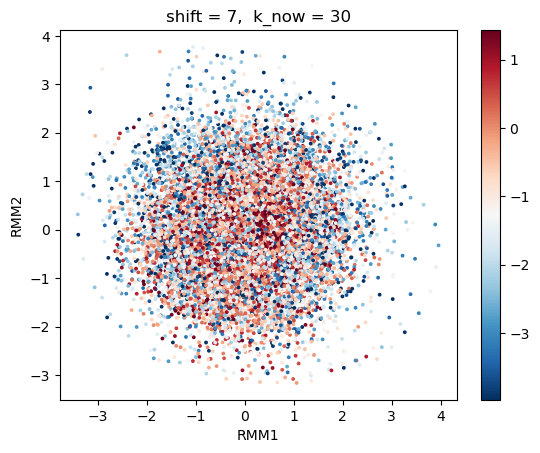

In [117]:
ccc,_,_ = robust_clip(div_daily,5,95)
plt.xlabel('RMM1')
plt.ylabel('RMM2')
plt.title(f'shift = {shift_now},  k_now = {k_now}')
plt.scatter(data_dynamical_system[:-shift_now ,0],data_dynamical_system[:-shift_now ,1],c=ccc,s=3,cmap='RdBu_r')
plt.colorbar()

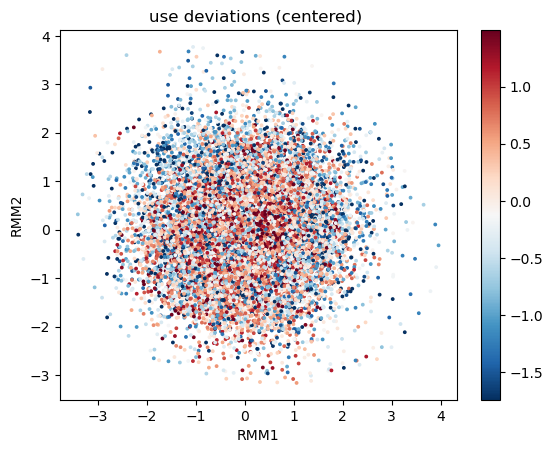

In [118]:
ccc,_,_ = robust_clip(normalize_array(div_daily),5,95)
plt.xlabel('RMM1')
plt.ylabel('RMM2')
plt.title('use deviations (centered) ')
plt.scatter(data_dynamical_system[:-shift_now ,0],data_dynamical_system[:-shift_now ,1],c=ccc,s=3,cmap='RdBu_r')
plt.colorbar()

In [119]:
running_var = np.empty((500,6))
for t in range(500): 
    for ii in range(6):
        idx_start  = idx_first_day[t] 
        running_var[t,ii] = data_dynamical_system[idx_start:idx_start+90,ii].var()

In [120]:
div_cumsum = np.empty(492) 
for t in range(492): 
    idx_start  = idx_first_day[t] 
    div_cumsum[t] = np.sum(div_daily[idx_start:idx_start+90])

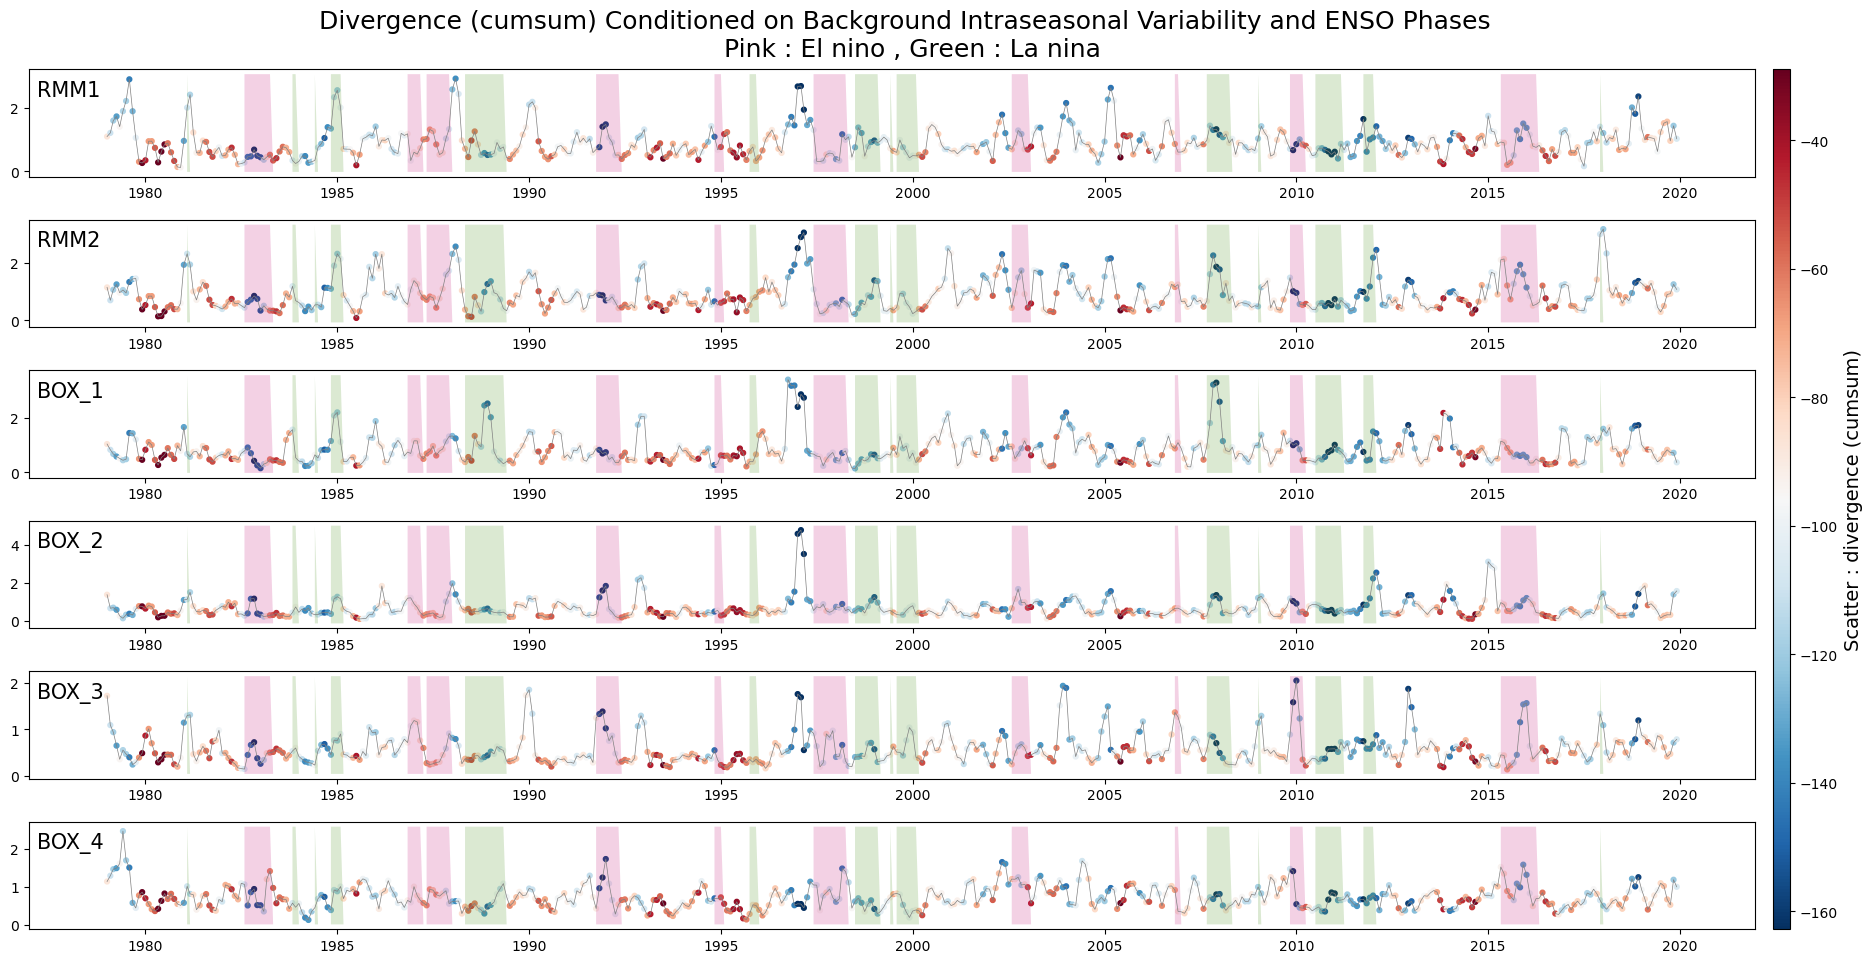

In [121]:
import numpy as np
import matplotlib.pyplot as plt

amp = np.nanpercentile(np.abs(div_cumsum-div_cumsum.mean()), 97) 
fig, ax = plt.subplots(6, 1, figsize=(20, 10))

# 只用前 500 個月（你原本就這樣做）
t_plot   = time_monthly[:492]
nino_da  = Nino_monthly_xr[:492]          # xarray DataArray
nino     = nino_da.values                 # 轉成 numpy
nino_std = nino_da.std().item()           # 標準差

# 閾值
thr = 1 * nino_std

# mask
mask_pos = nino >  thr
mask_neg = nino < -thr

# 取 PiYG 的兩端顏色
cmap      = plt.get_cmap("PiYG_r")
pos_color = cmap(0.9)   # 紫色那端（Pi）
neg_color = cmap(0.1)   # 綠色那端（YG）

for i in range(6):
    # 主軸：running var + 散點
    ax[i].plot(t_plot,
               running_var[:492, i],
               'grey', linewidth=0.5)
    
    
    
    
    im = ax[i].scatter(t_plot,
                       running_var[:492, i],
                       c=div_cumsum[:492],
                       cmap='RdBu_r', s=12,
                       vmin=div_cumsum.mean()-amp, vmax=div_cumsum.mean()+amp)

    
    ax[i].text(
        0.005, 0.90, data_labels[i],
        transform=ax[i].transAxes,
        ha="left", va="top",
        fontsize=15
    )
    
    #ax[i].set_title(data_labels[i])
    #fig.colorbar(im, ax=ax[i])


    # 副軸：Nino index + 陰影
    #ax2 = ax[i].twinx()
    #ax2.plot(t_plot, nino, 'r-', linewidth=0.7)

    # 先取得 y 範圍，陰影就填滿整個 y 軸高度
    y0, y1 = ax[i].get_ylim()

    # > +1.5σ 的區段
    ax[i].fill_between(
        t_plot, y0, y1,
        where=mask_pos,
        facecolor=pos_color,
        alpha=0.2,
        interpolate=True
    )

    # < −1.5σ 的區段
    ax[i].fill_between(
        t_plot, y0, y1,
        where=mask_neg,
        facecolor=neg_color,
        alpha=0.2,
        interpolate=True
    )
fig.suptitle(
    'Divergence (cumsum) Conditioned on Background Intraseasonal Variability and ENSO Phases \n Pink : El nino , Green : La nina',
    fontsize=18,
    y=0.98
)



fig.subplots_adjust(
    top=0.92,
    bottom=0.06,
    left=0.06,
    right=0.95,   # 現在可以放心縮
    hspace=0.40
)


cbar = fig.colorbar(
    im,
    ax=ax,
    orientation='vertical',
    fraction=0.02,
    pad=0.01,
    aspect=50
)

cbar.set_label('Scatter : divergence (cumsum)', fontsize=14)

#plt.tight_layout()
plt.savefig(fig_path+'3_running_var_and_enso_1227_running_skew.png',dpi=300)

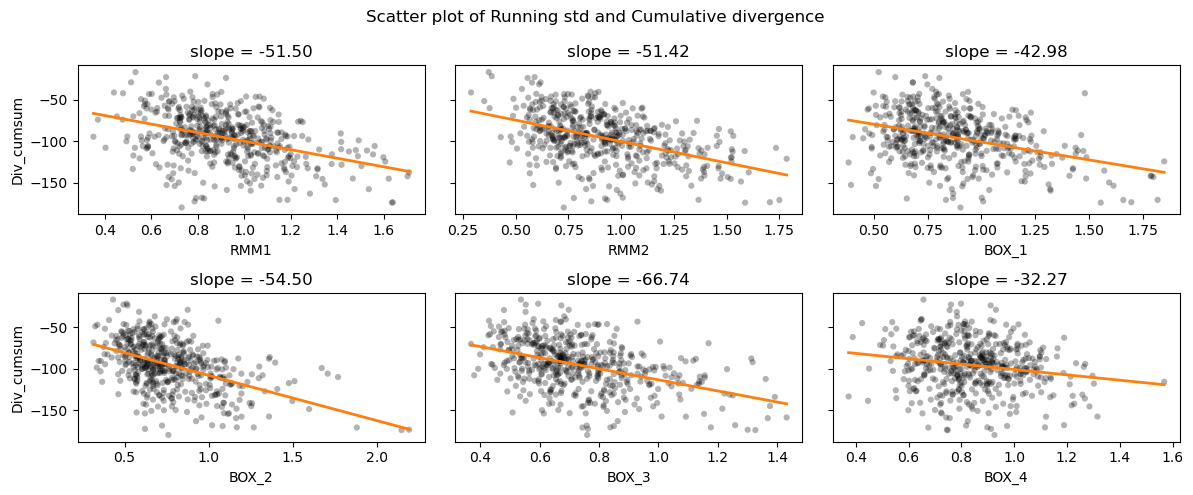

In [163]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(12, 5), sharey=True)

for i, ax_now in enumerate(ax.flatten()):

    x = np.sqrt(running_var[:492, i])
    # x = running_var[:492, i]
    y = div_cumsum

    # scatter
    ax_now.scatter(
        x, y,
        s=20,
        color=c_point,
        alpha=0.3,
        edgecolors="none",
        zorder=2
    )

    # -----------------------------
    # linear regression
    # -----------------------------
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    # fit y = a x + b
    a, b = np.polyfit(x_fit, y_fit, 1)

    # generate line
    x_line = np.linspace(np.nanmin(x_fit), np.nanmax(x_fit), 100)
    y_line = a * x_line + b

    # plot line
    ax_now.plot(
        x_line, y_line,
        color=(255/255,127/255,13/255),  # 你之前指定的橘色
        linewidth=2,
        zorder=3
    )

    # optional: show slope
    if i == 0 or i == 3 : 
        ax_now.set_ylabel('Div_cumsum') 
    ax_now.set_xlabel(data_labels[i])
    ax_now.set_title(f"slope = {a:.2f}")
plt.suptitle('Scatter plot of Running std and Cumulative divergence')
plt.tight_layout()
plt.savefig(fig_path+'run_std_and_div_cumsum_SI.png',dpi=300)

BOX_3


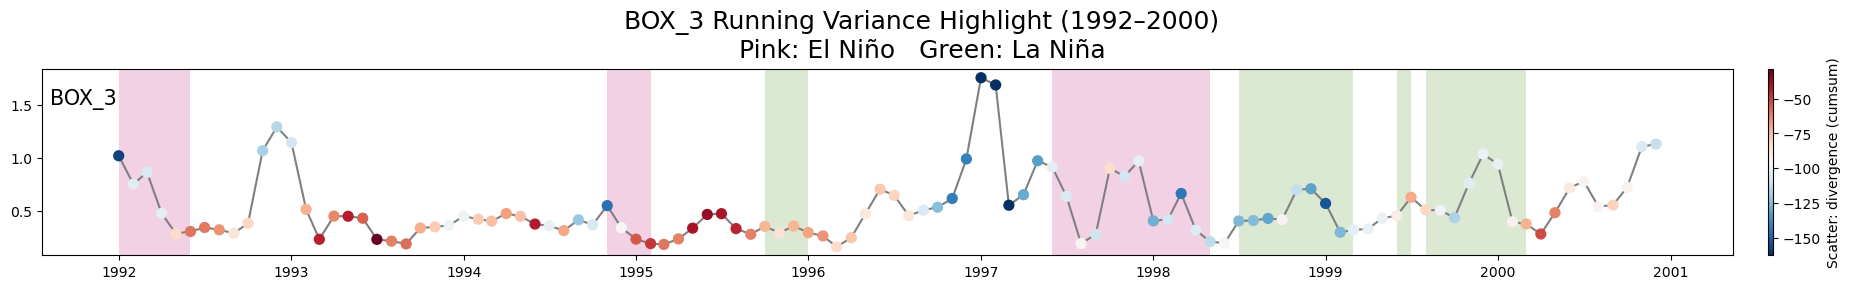

In [123]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# helper: convert boolean mask into contiguous time spans
# ============================================================
def find_spans(t, mask):
    """
    Parameters
    ----------
    t : 1D numpy array of datetime64
    mask : 1D boolean array

    Returns
    -------
    spans : list of (start, end)
        Each span is a contiguous True segment in mask.
    """
    t = np.asarray(t)
    mask = np.asarray(mask, dtype=bool)

    spans = []
    in_span = False
    start = None

    for i, m in enumerate(mask):
        if m and not in_span:
            start = t[i]
            in_span = True
        elif (not m) and in_span:
            end = t[i]
            spans.append((start, end))
            in_span = False

    if in_span:
        spans.append((start, t[-1]))

    return spans


# ============================================================
# basic settings
# ============================================================
amp = np.nanpercentile(np.abs(div_cumsum - div_cumsum.mean()), 97)

fig, ax = plt.subplots(1, 1, figsize=(20, 3))

# ------------------------------------------------------------
# data
# ------------------------------------------------------------
# convert time to pure numpy datetime64 array so matplotlib can use it
t_all = np.asarray(time_monthly[:492].values)

nino_da = Nino_monthly_xr[:492]
nino = nino_da.values
nino_std = nino_da.std().item()

thr = 1.0 * nino_std

mask_pos_all = nino >  thr
mask_neg_all = nino < -thr

# ------------------------------------------------------------
# select time window : 1992–2000
# ------------------------------------------------------------
time_mask = (t_all >= np.datetime64("1992-01-01")) & \
            (t_all <= np.datetime64("2000-12-31"))

t_plot   = t_all[time_mask]
var_plot = running_var[:492, 4][time_mask]   # RMM1 only ------------------------------------------------------------
div_plot = div_cumsum[:492][time_mask]
print(data_labels[4])
mask_pos = mask_pos_all[time_mask]
mask_neg = mask_neg_all[time_mask]

# ------------------------------------------------------------
# colors
# ------------------------------------------------------------
cmap_bg   = plt.get_cmap("PiYG_r")
pos_color = cmap_bg(0.9)   # pink side
neg_color = cmap_bg(0.1)   # green side

# ------------------------------------------------------------
# main line + scatter
# ------------------------------------------------------------
ax.plot(
    t_plot,
    var_plot,
    color="grey",
    linewidth=1.5,
    zorder=2
)

im = ax.scatter(
    t_plot,
    var_plot,
    c=div_plot,
    cmap="RdBu_r",
    s=50,
    vmin=div_cumsum.mean() - amp,
    vmax=div_cumsum.mean() + amp,
    zorder=3
)

# ------------------------------------------------------------
# rectangular ENSO shading
# ------------------------------------------------------------
pos_spans = find_spans(t_plot, mask_pos)
neg_spans = find_spans(t_plot, mask_neg)

for s, e in pos_spans:
    ax.axvspan(s, e, facecolor=pos_color, alpha=0.20, zorder=0)

for s, e in neg_spans:
    ax.axvspan(s, e, facecolor=neg_color, alpha=0.20, zorder=0)

# ------------------------------------------------------------
# label
# ------------------------------------------------------------
ax.text(
    0.005, 0.90, "BOX_3",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=15
)

# ------------------------------------------------------------
# title
# ------------------------------------------------------------
fig.suptitle(
    "BOX_3 Running Variance Highlight (1992–2000)\n"
    "Pink: El Niño   Green: La Niña",
    fontsize=18,
    y=0.98
)

# ------------------------------------------------------------
# layout
# ------------------------------------------------------------
fig.subplots_adjust(
    top=0.78,
    bottom=0.16,
    left=0.06,
    right=0.95
)

# ------------------------------------------------------------
# colorbar
# ------------------------------------------------------------
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.03,
    pad=0.02,
    aspect=40
)
cbar.set_label("Scatter: divergence (cumsum)")

# ------------------------------------------------------------
# save
# ------------------------------------------------------------
plt.savefig(
    fig_path + "BOX_3_running_var_highlight_1992_2000_rectangular_shading.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [124]:
ds_sst = xr.open_dataset('/work/kuoray/proj2_diffusion/ewss_related/data_sst_no_smooth_1102.nc')
print(ds_sst)
Nino_daily_00 = ds_sst['ENSO'][:-7].to_numpy()
box_sst_daily = ds_sst['BOX12ALL'][:-7].to_numpy()

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 15341)
Coordinates:
  * time         (time) datetime64[ns] 123kB 1979-01-01 ... 2020-12-31
Data variables: (12/21)
    ENSO         (time) float64 123kB ...
    NPMM         (time) float64 123kB ...
    SPMM         (time) float64 123kB ...
    IOB          (time) float64 123kB ...
    IOD (W)      (time) float64 123kB ...
    IOD (E)      (time) float64 123kB ...
    ...           ...
    BOX12MIDBIG  (time) float64 123kB ...
    NINO3        (time) float64 123kB ...
    TNA2         (time) float64 123kB ...
    IOD          (time) float64 123kB ...
    SIOD         (time) float64 123kB ...
    SASD         (time) float64 123kB ...
Attributes:
    description:  Calculated from 1102 tidyup running var and sst different b...


In [125]:
div_cumsum_normalized = normalize_array(div_cumsum)

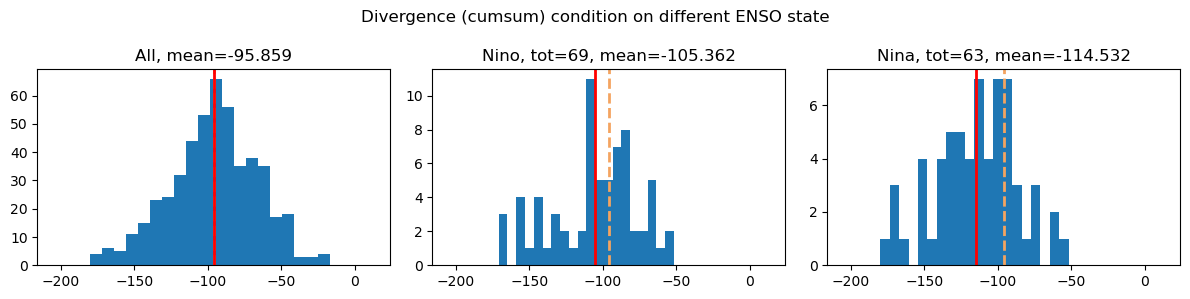

In [126]:
plt.figure(figsize=(12,3))
Nino_monthly_now = Nino_monthly_xr.to_numpy()[:492]
std_now = Nino_monthly_now.std()
mean_now = div_cumsum.mean()
# --- panel 1 : all ---
plt.subplot(131)
data_now = div_cumsum
plt.hist(data_now, 20)
plt.axvline(mean_now, color='sandybrown', linestyle='--', linewidth=2)
plt.axvline(data_now.mean(), color='r', linewidth=2)
plt.title(f'All, mean={data_now.mean():.3f}')
plt.xlim(mean_now-120, mean_now+120)


# --- panel 2 : Nino ---
plt.subplot(132)
data_now = div_cumsum[Nino_monthly_now > std_now]
plt.hist(data_now, 20)
plt.axvline(mean_now, color='sandybrown', linestyle='--', linewidth=2)
plt.axvline(data_now.mean(), color='r', linewidth=2)
plt.title(f'Nino, tot={len(data_now)}, mean={data_now.mean():.3f}')
plt.xlim(mean_now-120, mean_now+120)


# --- panel 3 : Nina ---
plt.subplot(133)
data_now = div_cumsum[Nino_monthly_now < -std_now]
plt.hist(data_now, 20)
plt.axvline(mean_now, color='sandybrown', linestyle='--', linewidth=2)
plt.axvline(data_now.mean(), color='r', linewidth=2)
plt.title(f'Nina, tot={len(data_now)}, mean={data_now.mean():.3f}')
plt.xlim(mean_now-120, mean_now+120)

plt.suptitle('Divergence (cumsum) condition on different ENSO state')
plt.tight_layout()

plt.savefig(fig_path+'4_div_cond_on_enso.png',dpi=300)

Text(0, 0.5, 'SSTA at Nino3.4 area')

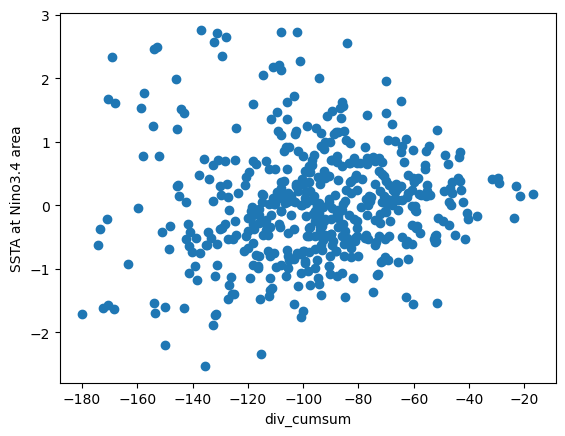

In [127]:
fig = plt.figure()
plt.scatter(div_cumsum,Nino_monthly_now)
plt.xlabel('div_cumsum')
plt.ylabel('SSTA at Nino3.4 area')

/tmp/ipykernel_2254772/1746076051.py:234: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


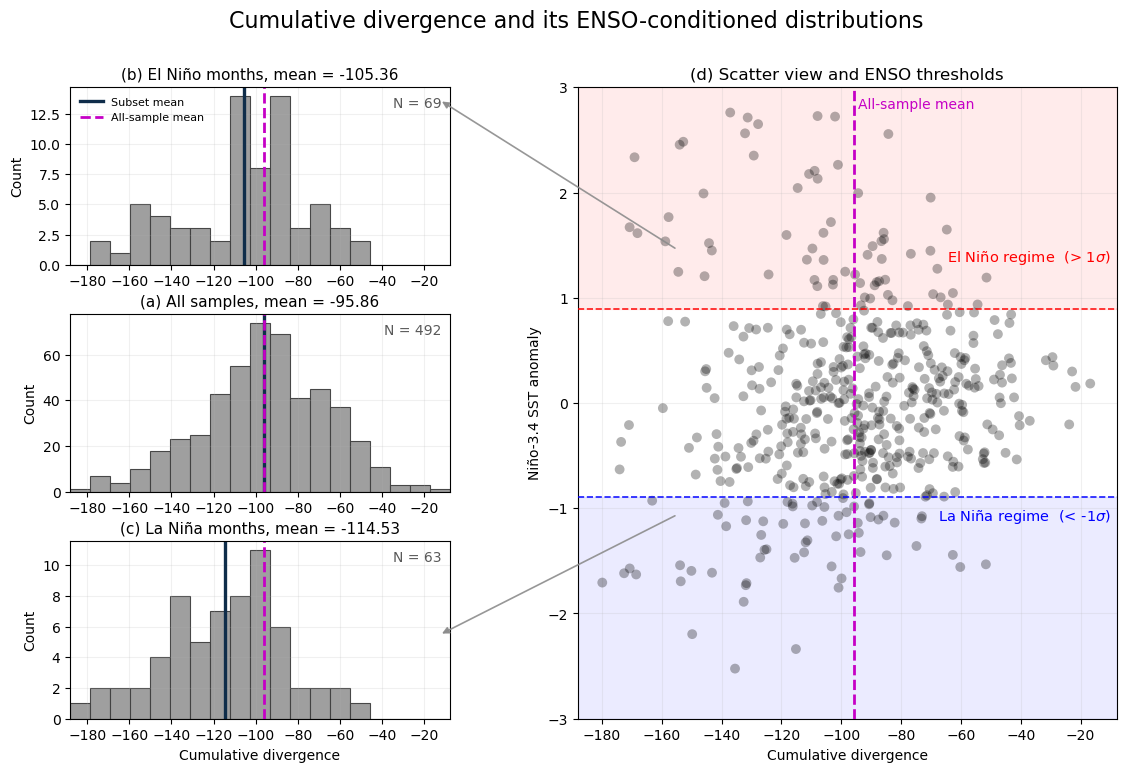

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch

# ============================================================
# data
# ============================================================
Nino_monthly_now = Nino_monthly_xr.to_numpy()[:492]
x = div_cumsum
y = Nino_monthly_now

std_now  = y.std()
mean_all = x.mean()

mask_nino = y > std_now
mask_nina = y < -std_now

# ------------------------------------------------------------
# use ONE common x-range for all panels
# (left histograms and right scatter share the same xlim)
# ------------------------------------------------------------
xpad = 8
xmin = np.floor(np.min(x)) - xpad
xmax = np.ceil(np.max(x)) + xpad
xlim = (xmin, xmax)

# common histogram bins across all histogram panels
bins = np.linspace(xlim[0], xlim[1], 20)

# ============================================================
# colors
# ============================================================
c_hist  = "#9A9A9A"   # histogram gray
#c_point = "#7F7F7F"   # scatter gray
c_point = "k"
c_edge  = "0.25"      # histogram edge dark gray
c_link  = "0.55"      # connection line gray

c_all   = "#C500C5"
#c_all   = "#9C7A00"   # darker golden-brown: all mean
c_cond  = "#0F2D4A"   # darker navy: subset mean

c_nino  = "red"
c_nina  = "blue" 
#c_nino  = "#CC6677"   # muted red
#c_nina  = "#4477AA"   # muted blue

# ============================================================
# figure layout
# ============================================================
fig = plt.figure(figsize=(13.5, 8.2))
gs = GridSpec(
    3, 2,
    width_ratios=[1.0, 1.42],
    height_ratios=[1, 1, 1],
    wspace=0.28,
    hspace=0.28
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[:, 1])

# ============================================================
# helper for histogram panels
# ============================================================
def hist_panel(ax, data, panel_title, N_value,
               show_xlabel=False, show_all_mean=False):
    ax.hist(
        data,
        bins=bins,
        color=c_hist,
        edgecolor=c_edge,
        linewidth=0.8,
        alpha=0.95
    )



    # subset mean
    ax.axvline(
        np.mean(data),
        color=c_cond,
        linewidth=2.4
    )

        # all-sample mean reference
    if show_all_mean:
        ax.axvline(
            mean_all,
            color=c_all,
            linestyle="--",
            linewidth=2.0
        )

    ax.set_xlim(*xlim)
    ax.set_title(f"{panel_title}, mean = {np.mean(data):.2f}", fontsize=11, pad=6)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.18)

    # put N at upper-right corner
    ax.text(
        0.98, 0.95,
        f"N = {N_value}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=10, color="0.35"
    )

    if show_xlabel:
        ax.set_xlabel("Cumulative divergence")

# ============================================================
# left column: histograms
# ============================================================
hist_panel(
    ax2, x,
    panel_title="(a) All samples",
    N_value=len(x),
    show_xlabel=False,
    show_all_mean=True
)

hist_panel(
    ax1, x[mask_nino],
    panel_title="(b) El Niño months",
    N_value=mask_nino.sum(),
    show_xlabel=False,
    show_all_mean=True
)

hist_panel(
    ax3, x[mask_nina],
    panel_title="(c) La Niña months",
    N_value=mask_nina.sum(),
    show_xlabel=True,
    show_all_mean=True
)

# legend only once, in a location that avoids overlap
legend_handles = [
    plt.Line2D([0], [0], color=c_cond, lw=2.4, label="Subset mean"),
    plt.Line2D([0], [0], color=c_all, lw=2.0, linestyle="--", label="All-sample mean")
]
ax1.legend(handles=legend_handles, loc="upper left", frameon=False, fontsize=8)




#==============================================================================================================================================
# ============================================================
# right column: scatter
# ============================================================
ax4.scatter(
    x, y,
    s=50,                 # smaller points to reveal density shape
    color=c_point,
    alpha=0.3,            # transparency helps the crescent shape emerge
    edgecolors="none",
    zorder=2
)

# fixed y-limits
ax4.set_ylim(-3, 3)

# same x-limits as histograms
ax4.set_xlim(*xlim)
xlim_now = ax4.get_xlim()

# soft ENSO-state shading
ax4.axhspan(std_now, 3, color=c_nino, alpha=0.08, zorder=0)
ax4.axhspan(-3, -std_now, color=c_nina, alpha=0.08, zorder=0)

# ENSO threshold lines
ax4.axhline(std_now,  color=c_nino, linestyle="--", linewidth=1.2, alpha=0.9, zorder=3)
ax4.axhline(-std_now, color=c_nina, linestyle="--", linewidth=1.2, alpha=0.9, zorder=3)

# all-sample mean reference line
ax4.axvline(mean_all, color=c_all, linestyle="--", linewidth=2.0, zorder=3)

ax4.set_xlabel("Cumulative divergence")
ax4.set_ylabel("Niño-3.4 SST anomaly")
ax4.set_title("(d) Scatter view and ENSO thresholds", fontsize=12, pad=6)
ax4.grid(alpha=0.18)

# labels on scatter
ax4.text(
    xlim_now[1] - 2, 1.3,
    r"El Niño regime  (> 1$\sigma$)",
    color=c_nino, ha="right", va="bottom", fontsize=10.5
)
ax4.text(
    xlim_now[1] - 2, -std_now - 0.10,
    r"La Niña regime  (< -1$\sigma$)",
    color=c_nina, ha="right", va="top", fontsize=10.5
)
ax4.text(
    mean_all + 1.5, 2.90,
    "All-sample mean",
    color=c_all, ha="left", va="top", fontsize=10
)

# ============================================================
# subtle connection lines
# =======================================================================================================================================================================================================================================
shift_for_graph_now=0.4

con2 = ConnectionPatch(
    xyA=(xlim_now[0] + 0.18*(xlim_now[1]-xlim_now[0]),  std_now + 0.18+shift_for_graph_now), coordsA=ax4.transData,
    xyB=(0.98, 0.52+shift_for_graph_now),                                 coordsB=ax1.transAxes,
    color=c_link, linewidth=1.2, alpha=0.9,
    arrowstyle="-|>"
)
con3 = ConnectionPatch(
    xyA=(xlim_now[0] + 0.18*(xlim_now[1]-xlim_now[0]), -std_now - 0.18), coordsA=ax4.transData,
    xyB=(0.98, 0.48),                                  coordsB=ax3.transAxes,
    color=c_link, linewidth=1.2, alpha=0.9,
    arrowstyle="-|>"
)

fig.add_artist(con2)
fig.add_artist(con3)

# ============================================================
# overall title
# ============================================================
fig.suptitle(
    "Cumulative divergence and its ENSO-conditioned distributions",
    fontsize=16, y=0.975
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(
    fig_path + "4_divergence_enso_conditional_graystyle.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [129]:
fig_path

'/home/kuoray/Master/proj2_diffusion/ENSO/WWB /wwb and entropy/final_version/figs/'

In [130]:
from scipy.stats import gaussian_kde

def kde_multivariate(data):
    """
    Multivariate KDE for data shape (T, dim_x)

    Returns
    -------
    kde : scipy gaussian_kde object
    """
    data = np.asarray(data)
    kde = gaussian_kde(data.T)  # note transpose!
    return kde
X = np.column_stack([div_cumsum,Nino_monthly_now])
kde = kde_multivariate(X)

xg = np.linspace(X[:,0].min(), X[:,0].max(), 100)
yg = np.linspace(X[:,1].min(), X[:,1].max(), 100)
Xg, Yg = np.meshgrid(xg, yg)

pdf = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)

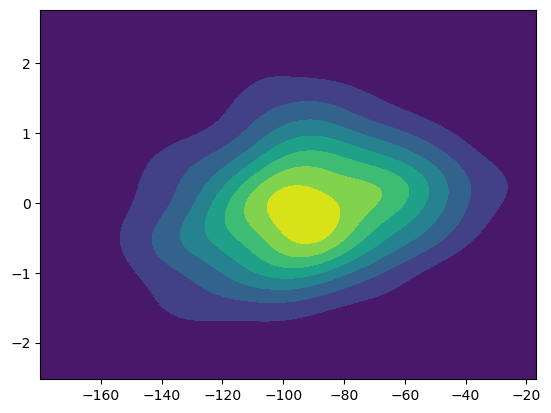

In [131]:
plt.contourf(Xg,Yg,pdf)

# 3 : contour map 

## Functions 

In [132]:
starts_for_box = [110 ,140 ,170,-160]
ends_for_box   = [140 ,170,-160,-120]

In [133]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

def _box_center_lon(lon1, lon2):
    """
    Return box center longitude handling dateline crossing.
    Inputs lon1, lon2 can be in [-180,180] or [0,360] style.
    Output in [-180,180).
    """
    a = lon1 % 360
    b = lon2 % 360
    # if crossing dateline in [0,360): e.g. 170 -> 200 (i.e., -160)
    if b < a:
        b += 360
    c = 0.5 * (a + b)
    c = c % 360
    # back to [-180,180)
    if c >= 180:
        c -= 360
    return c

def _stroke_line(line, fg="black", lw=3):
    line.set_path_effects([pe.Stroke(linewidth=lw, foreground=fg), pe.Normal()])
    return line


def the_plot(
    corr_map,
    title,
    center,
    lon_sst,
    lat_sst,
    starts_for_box,
    ends_for_box,
    pct=90,
    cmap="RdBu_r",
    figsize=(20,4),
    central_longitude=180,
    plot_npmm = True
):

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    # ----------------------------------------
    # symmetric color scale
    # ----------------------------------------
    amp = np.nanpercentile(np.abs(corr_map-center), pct)

    norm = mcolors.TwoSlopeNorm(
        vcenter=center,
        vmin=center-amp,
        vmax=center+amp
    )

    im = ax.pcolormesh(
        lon_sst,
        lat_sst,
        corr_map,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        shading="auto",
        rasterized=True
    )

    # ----------------------------------------
    # coastlines
    # ----------------------------------------
    ax.coastlines(resolution="110m", linewidth=0.7, color="k")
    ax.add_feature(cfeature.BORDERS.with_scale("110m"), linewidth=0.3, color="k")

    # ----------------------------------------
    # Yellow multi boxes
    # ----------------------------------------
    y1, y2 = -10, 10

    for i, x in enumerate(list(starts_for_box) + [ends_for_box[-1]]):

        line = ax.plot(
            [x, x],
            [y1, y2],
            transform=ccrs.PlateCarree(),
            color="yellow",
            linewidth=2,
            zorder=4
        )[0]
        _stroke_line(line)

        # ----- BOX label (move to SOUTH) -----
        if i < len(starts_for_box):
            lon_c = _box_center_lon(starts_for_box[i], ends_for_box[i])
            lat_c = y1 - 1  # south of the box

            ax.text(
                lon_c,
                lat_c,
                f"BOX{i+1}",
                transform=ccrs.PlateCarree(),
                ha="center",
                va="top",
                fontsize=11,
                weight="bold",
                color="yellow",
                path_effects=[pe.withStroke(linewidth=3, foreground="black")]
            )

    for y in [y1, y2]:

        line = ax.plot(
            [110, 180],
            [y, y],
            transform=ccrs.PlateCarree(),
            color="yellow",
            linewidth=2,
            zorder=4
        )[0]
        _stroke_line(line)

        line = ax.plot(
            [-180, -120],
            [y, y],
            transform=ccrs.PlateCarree(),
            color="yellow",
            linewidth=2,
            zorder=4
        )[0]
        _stroke_line(line)

    # ----------------------------------------
    # Nino3.4 box  (red, stroked)
    # ----------------------------------------
    for x in [-170, -120]:
        line = ax.plot(
            [x, x],
            [-5, 5],
            transform=ccrs.PlateCarree(),
            color="lime",
            linewidth=2,
            zorder=4
        )[0]
        _stroke_line(line)

    for y in [-5, 5]:
        line = ax.plot(
            [-170, -120],
            [y, y],
            transform=ccrs.PlateCarree(),
            color="lime",
            linewidth=2,
            zorder=4
        )[0]
        _stroke_line(line)

    ax.text(
        (-170 - 120) / 2,
        0,
        "Nino3.4",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=11,
        weight="bold",
        color="lime",
        path_effects=[pe.withStroke(linewidth=3, foreground="black")]
    )
    if plot_npmm == True : 
        # ----------------------------------------
        # NPMM box: 160°–120°W, 10°–25°N  (same format as Nino3.4)
        # ----------------------------------------
        # lon in [-180, 180]: 160W=-160, 120W=-120
        npmm_lon1, npmm_lon2 = -160, -120
        npmm_lat1, npmm_lat2 = 10, 25
    
        for x in [npmm_lon1, npmm_lon2]:
            line = ax.plot(
                [x, x],
                [npmm_lat1, npmm_lat2],
                transform=ccrs.PlateCarree(),
                color="lime",
                linewidth=2,
                zorder=4
            )[0]
            _stroke_line(line)
    
        for y in [npmm_lat1, npmm_lat2]:
            line = ax.plot(
                [npmm_lon1, npmm_lon2],
                [y, y],
                transform=ccrs.PlateCarree(),
                color="lime",
                linewidth=2,
                zorder=4
            )[0]
            _stroke_line(line)
    
        ax.text(
            (npmm_lon1 + npmm_lon2) / 2,
            (npmm_lat1 + npmm_lat2) / 2,
            "NPMM",
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=11,
            weight="bold",
            color="lime",
            path_effects=[pe.withStroke(linewidth=3, foreground="black")]
        )
    # ----------------------------------------
    # colorbar
    # ----------------------------------------
    plt.colorbar(im, ax=ax, orientation="vertical")

    # ----------------------------------------
    # axis formatting
    # ----------------------------------------
    ax.set_xticks([110,140,170,-160,-120], crs=ccrs.PlateCarree())
    ax.set_xlim(-90,90)

    ax.set_yticks([-10,-5,0,5,10], crs=ccrs.PlateCarree())

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=10)

    ax.set_title(title)

    plt.tight_layout()

    return fig, ax

# Graph 

In [134]:
import xarray as xr

In [135]:
# SST 
sst_xr = xr.open_dataset('/work/kuoray/proj2_diffusion/sst_anomaly_all_area_lon_all.nc')
#sst_xr_ori = sst_xr
#print(sst_xr_ori['valid_time'][-1])
sst_xr = sst_xr.sel(valid_time=slice('1979-01-01','2020-12-31'))
lon_sst = sst_xr['longitude'] # 30 ~ -30 
lat_sst = sst_xr['latitude']  # -180 ~ 180
#sst_xr
sst_np = sst_xr['sst'].to_numpy()
print(sst_np.shape)
sst_monthly_xr = sst_xr.resample(valid_time="MS").mean()

(15341, 241, 1440)


In [136]:
sst_np_monthly = sst_monthly_xr['sst'].to_numpy()[:492]
print(sst_np_monthly.shape)

(492, 241, 1440)


In [137]:
print(lon_sst[-1],lon_sst[0])
print(lat_sst[-1],lat_sst[0])

<xarray.DataArray 'longitude' ()> Size: 8B
array(179.75)
Coordinates:
    longitude  float64 8B 179.8
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude <xarray.DataArray 'longitude' ()> Size: 8B
array(-180.)
Coordinates:
    longitude  float64 8B -180.0
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude
<xarray.DataArray 'latitude' ()> Size: 8B
array(-30.)
Coordinates:
    latitude  float64 8B -30.0
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing <xarray.DataArray 'latitude' ()> Size: 8B
array(30.)
Coordinates:
    latitude  float64 8B 30.0
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing


In [138]:
import numpy as np
from scipy.stats import skew  # 你若之後要算 skew 可用

# sst_monthly_np: (time, lat, lon)
# div_cumsum: (time,)
# lat_sst, lon_sst: 1D arrays giving lat/lon

# 1. Precompute SST std at each grid point
sst_std_grid = sst_np_monthly.std(axis=0)  # (lat, lon)

# 2. Build thresholds and masks (broadcast over time)
thr = sst_std_grid          # (lat, lon)
thr_3d = thr[None, :, :]          # (1, lat, lon)

mask_big   = sst_np_monthly >  thr_3d   # (time, lat, lon)
mask_small = sst_np_monthly < -thr_3d   # (time, lat, lon)

# 3. Broadcast div_cumsum to 3D and mask with NaNs
div_3d = div_cumsum[:, None, None]  # (time, 1, 1) -> broadcasts

# Positive (big) SST cases
div_big   = np.where(mask_big,   div_3d, np.nan)  # (time, lat, lon)

# Negative (small) SST cases
div_small = np.where(mask_small, div_3d, np.nan)

# 4. Compute mean along time (axis=0), ignoring NaNs
mean_grid_big   = np.nanmean(div_big,   axis=0)  # (lat, lon)
mean_grid_small = np.nanmean(div_small, axis=0)  # (lat, lon)

# (optional) skew along time (axis=0), ignoring NaNs
# mean_grid_big_skew   = skew(div_big,   axis=0, nan_policy="omit")
# mean_grid_small_skew = skew(div_small, axis=0, nan_policy="omit")

/tmp/ipykernel_2254772/3981159619.py:28: RuntimeWarning: Mean of empty slice
  mean_grid_big   = np.nanmean(div_big,   axis=0)  # (lat, lon)
/tmp/ipykernel_2254772/3981159619.py:29: RuntimeWarning: Mean of empty slice
  mean_grid_small = np.nanmean(div_small, axis=0)  # (lat, lon)


/home/kuoray/miniconda3/envs/torch310/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


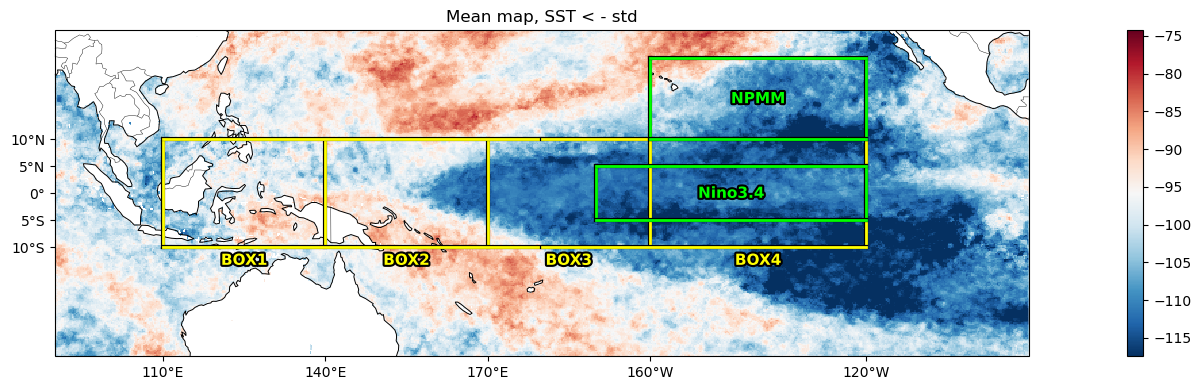

/home/kuoray/miniconda3/envs/torch310/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


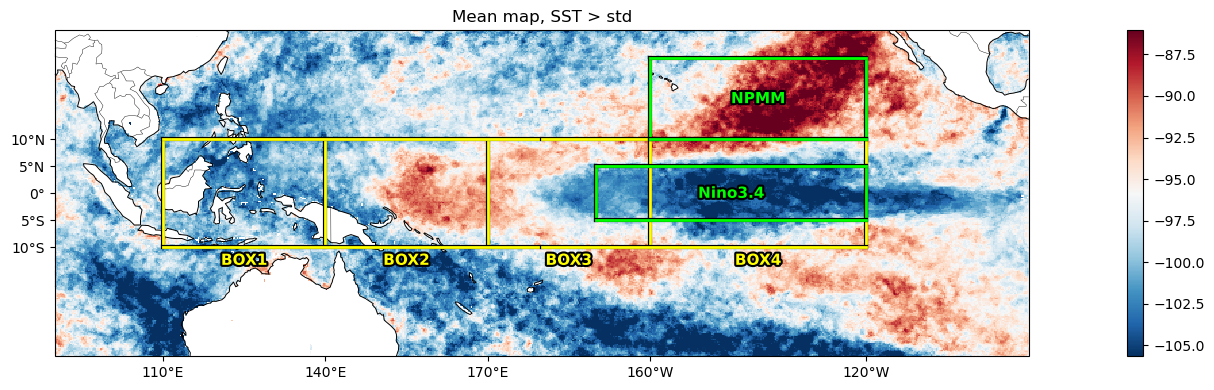

In [139]:
the_plot(mean_grid_small,'Mean map, SST < - std',center=div_cumsum.mean(), lon_sst=lon_sst, lat_sst=lat_sst,
        starts_for_box=starts_for_box, ends_for_box=ends_for_box, pct=97)
plt.savefig(fig_path+'5_mean_map_small.png',dpi=300)
plt.show()


the_plot(mean_grid_big,'Mean map, SST > std',center=div_cumsum.mean(), lon_sst=lon_sst, lat_sst=lat_sst,
        starts_for_box=starts_for_box, ends_for_box=ends_for_box, pct=97)
plt.savefig(fig_path+'5_mean_map_big.png',dpi=300)
plt.show()

In [140]:
div_cumsum.mean()

-95.8590426841757

/home/kuoray/miniconda3/envs/torch310/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/kuoray/miniconda3/envs/torch310/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


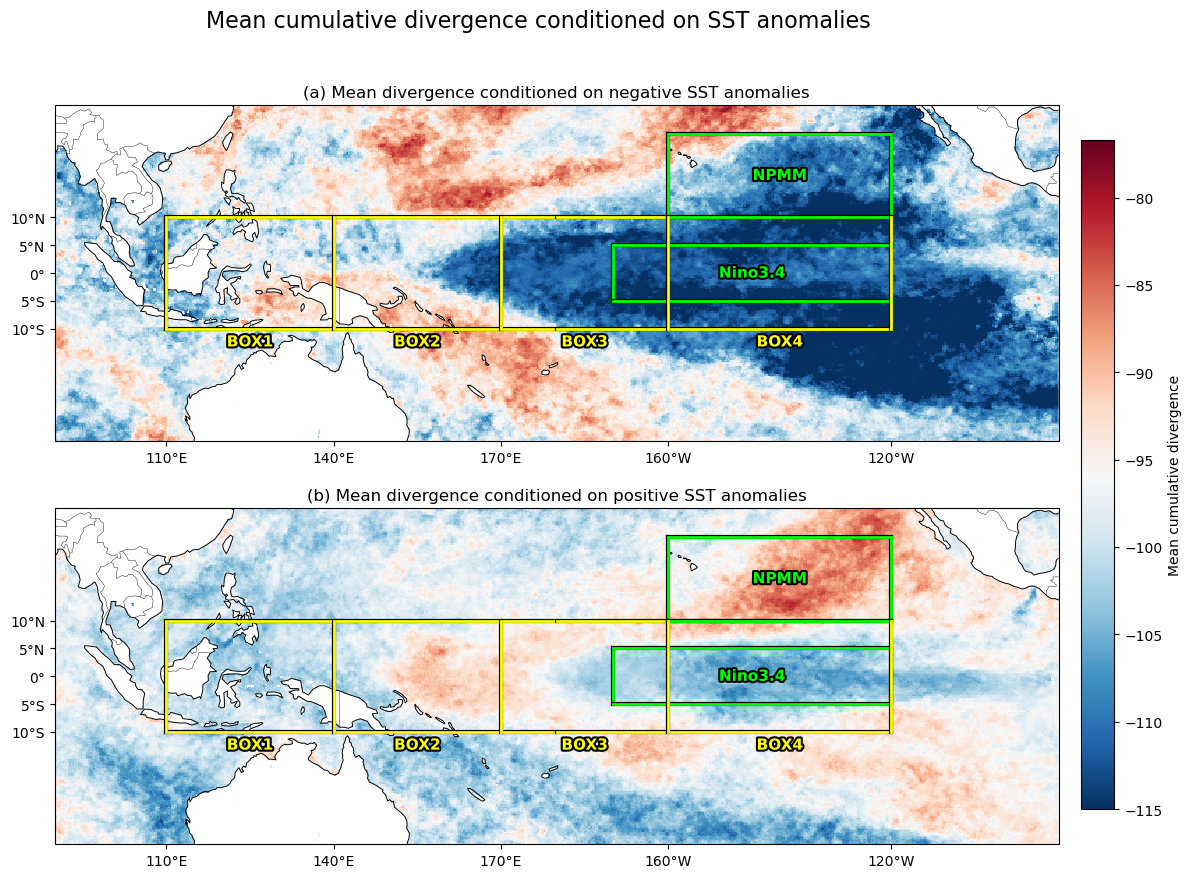

In [165]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

# ============================================================
# helper functions
# ============================================================
def _box_center_lon(lon1, lon2):
    a = lon1 % 360
    b = lon2 % 360
    if b < a:
        b += 360
    c = 0.5 * (a + b)
    c = c % 360
    if c >= 180:
        c -= 360
    return c

def _stroke_line(line, fg="black", lw=3):
    line.set_path_effects([pe.Stroke(linewidth=lw, foreground=fg), pe.Normal()])
    return line

# ============================================================
# global normalization (KEY PART)
# ============================================================
center = div_cumsum.mean()

all_data = np.concatenate([
    (mean_grid_small - center).ravel(),
    (mean_grid_big   - center).ravel()
])

amp = np.nanpercentile(np.abs(all_data), 97)

norm = mcolors.TwoSlopeNorm(
    vcenter=center,
    vmin=center - amp,
    vmax=center + amp
)

# ============================================================
# plotting function
# ============================================================
def draw_panel(
    ax,
    corr_map,
    title,
    lon_sst,
    lat_sst,
    starts_for_box,
    ends_for_box,
    cmap="RdBu_r"
):

    im = ax.pcolormesh(
        lon_sst,
        lat_sst,
        corr_map,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        shading="auto",
        rasterized=True
    )

    # coastlines
    ax.coastlines(resolution="110m", linewidth=0.7, color="k")
    ax.add_feature(cfeature.BORDERS.with_scale("110m"), linewidth=0.3, color="k")

    # ----------------------------------------
    # Yellow boxes
    # ----------------------------------------
    y1, y2 = -10, 10

    for i, x in enumerate(list(starts_for_box) + [ends_for_box[-1]]):

        line = ax.plot(
            [x, x],
            [y1, y2],
            transform=ccrs.PlateCarree(),
            color="yellow",
            linewidth=2,
            zorder=4
        )[0]
        _stroke_line(line)

        if i < len(starts_for_box):
            lon_c = _box_center_lon(starts_for_box[i], ends_for_box[i])
            lat_c = y1 - 1

            ax.text(
                lon_c,
                lat_c,
                f"BOX{i+1}",
                transform=ccrs.PlateCarree(),
                ha="center",
                va="top",
                fontsize=11,
                weight="bold",
                color="yellow",
                path_effects=[pe.withStroke(linewidth=3, foreground="black")]
            )

    for y in [y1, y2]:
        line = ax.plot([110,180],[y,y],transform=ccrs.PlateCarree(),color="yellow",linewidth=2)[0]
        _stroke_line(line)
        line = ax.plot([-180,-120],[y,y],transform=ccrs.PlateCarree(),color="yellow",linewidth=2)[0]
        _stroke_line(line)

    # ----------------------------------------
    # Nino3.4
    # ----------------------------------------
    for x in [-170,-120]:
        _stroke_line(ax.plot([x,x],[-5,5],transform=ccrs.PlateCarree(),color="lime",linewidth=2)[0])
    for y in [-5,5]:
        _stroke_line(ax.plot([-170,-120],[y,y],transform=ccrs.PlateCarree(),color="lime",linewidth=2)[0])

    ax.text(
        (-170-120)/2,
        0,
        "Nino3.4",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=11,
        weight="bold",
        color="lime",
        path_effects=[pe.withStroke(linewidth=3, foreground="black")]
    )

    # ----------------------------------------
    # NPMM
    # ----------------------------------------
    npmm_lon1, npmm_lon2 = -160, -120
    npmm_lat1, npmm_lat2 = 10, 25

    for x in [npmm_lon1,npmm_lon2]:
        _stroke_line(ax.plot([x,x],[npmm_lat1,npmm_lat2],
                            transform=ccrs.PlateCarree(),
                            color="lime",
                            linewidth=2)[0])
    for y in [npmm_lat1,npmm_lat2]:
        _stroke_line(ax.plot([npmm_lon1,npmm_lon2],[y,y],
                            transform=ccrs.PlateCarree(),
                            color="lime",
                            linewidth=2)[0])

    ax.text(
        (npmm_lon1+npmm_lon2)/2,
        (npmm_lat1+npmm_lat2)/2,
        "NPMM",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=11,
        weight="bold",
        color="lime",
        path_effects=[pe.withStroke(linewidth=3, foreground="black")]
    )

    # axis
    ax.set_xticks([110,140,170,-160,-120], crs=ccrs.PlateCarree())
    ax.set_xlim(-90,90)
    ax.set_yticks([-10,-5,0,5,10], crs=ccrs.PlateCarree())

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.set_title(title)

    return im

# ============================================================
# plotting
# ============================================================
fig, axs = plt.subplots(
    2,1,
    figsize=(12*1.2,8*1.2),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)}
)

im1 = draw_panel(
    axs[0],
    mean_grid_small,
    "(a) Mean divergence conditioned on negative SST anomalies",
    lon_sst,
    lat_sst,
    starts_for_box,
    ends_for_box
)

im2 = draw_panel(
    axs[1],
    mean_grid_big,
    "(b) Mean divergence conditioned on positive SST anomalies",
    lon_sst,
    lat_sst,
    starts_for_box,
    ends_for_box
)

# ============================================================
# shared colorbar
# ============================================================
cbar = fig.colorbar(
    im1,
    ax=axs,
    orientation="vertical",
    fraction=0.03,
    pad=0.02
)

cbar.set_label("Mean cumulative divergence")

# ============================================================
fig.suptitle(
    "Mean cumulative divergence conditioned on SST anomalies",
    fontsize=16
)

plt.savefig(
    fig_path+"5_mean_map_enso_condition_vertical.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# AVG_IEWS exp. var. 

In [171]:
# Wind stress 
ds_ewss = xr.open_dataset("/work/kuoray/proj2_diffusion/ewss_related/mean_ewss_big_anomaly.nc")
ds_ewss = ds_ewss.sel(latitude=slice(30,-30))
print('1')
ds_ewss = ds_ewss.resample(valid_time="1D").mean()
print('2')
ewss    =  ds_ewss['avg_iews'][:] 
print('3')
lon_ewss     = ds_ewss['longitude'][:]
lat_ewss     = ds_ewss['latitude'][:]
time_daily   = ds_ewss['valid_time'][:]
len_lon = len(lon_ewss) # 110 ~ -120 
len_lat = len(lat_ewss) # 10 ~ -10  
#ds_ewss

1
2
3


In [172]:
from scipy.ndimage import uniform_filter1d
ewss_smthed = uniform_filter1d(ewss.to_numpy(), size=5, axis=0, mode='reflect')

In [173]:
ewss_smthed.shape

(15341, 241, 1440)

In [174]:
def the_plot_modified_contourf(
    corr_map,
    title,
    lon_sst,
    lat_sst,
    starts_for_box,
    ends_for_box,
    pct=90,
    cmap="magma",
    figsize=(20,4),
    central_longitude=180,
    plot_npmm=True
):

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    # ----------------------------------------
    # sequential color scale
    # ----------------------------------------
    #vmax = np.nanpercentile(corr_map, pct)
    #vmin = np.nanpercentile(corr_map, 100-pct)
    levels = np.arange(0.2, 0.81, 0.1)
    
    im = ax.contourf(
        lon_sst,
        lat_sst,
        corr_map,
        levels=levels,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        extend="neither"
    )

    # ----------------------------------------
    # coastlines
    # ----------------------------------------
    ax.coastlines(resolution="110m", linewidth=0.7, color="k")
    ax.add_feature(cfeature.BORDERS.with_scale("110m"), linewidth=0.3, color="k")

    # ----------------------------------------
    # Yellow multi boxes
    # ----------------------------------------
    y1, y2 = -10, 10

    for i, x in enumerate(list(starts_for_box) + [ends_for_box[-1]]):

        line = ax.plot(
            [x, x],
            [y1, y2],
            transform=ccrs.PlateCarree(),
            color="yellow",
            linewidth=2,
            zorder=4
        )[0]
        _stroke_line(line)

        if i < len(starts_for_box):
            lon_c = _box_center_lon(starts_for_box[i], ends_for_box[i])
            lat_c = y1 - 1

            ax.text(
                lon_c,
                lat_c,
                f"BOX{i+1}",
                transform=ccrs.PlateCarree(),
                ha="center",
                va="top",
                fontsize=11,
                weight="bold",
                color="yellow",
                path_effects=[pe.withStroke(linewidth=3, foreground="black")]
            )

    for y in [y1, y2]:

        line = ax.plot(
            [110, 180],
            [y, y],
            transform=ccrs.PlateCarree(),
            color="yellow",
            linewidth=2,
            zorder=4
        )[0]
        _stroke_line(line)

        line = ax.plot(
            [-180, -120],
            [y, y],
            transform=ccrs.PlateCarree(),
            color="yellow",
            linewidth=2,
            zorder=4
        )[0]
        _stroke_line(line)

    # ----------------------------------------
    # Nino3.4 box
    # ----------------------------------------
    for x in [-170, -120]:
        line = ax.plot(
            [x, x],
            [-5, 5],
            transform=ccrs.PlateCarree(),
            color="lime",
            linewidth=2,
            zorder=4
        )[0]
        _stroke_line(line)

    for y in [-5, 5]:
        line = ax.plot(
            [-170, -120],
            [y, y],
            transform=ccrs.PlateCarree(),
            color="lime",
            linewidth=2,
            zorder=4
        )[0]
        _stroke_line(line)

    ax.text(
        (-170 - 120) / 2,
        0,
        "Nino3.4",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=11,
        weight="bold",
        color="lime",
        path_effects=[pe.withStroke(linewidth=3, foreground="black")]
    )

    if plot_npmm:

        npmm_lon1, npmm_lon2 = -160, -120
        npmm_lat1, npmm_lat2 = 10, 25

        for x in [npmm_lon1, npmm_lon2]:
            line = ax.plot(
                [x, x],
                [npmm_lat1, npmm_lat2],
                transform=ccrs.PlateCarree(),
                color="lime",
                linewidth=2,
                zorder=4
            )[0]
            _stroke_line(line)

        for y in [npmm_lat1, npmm_lat2]:
            line = ax.plot(
                [npmm_lon1, npmm_lon2],
                [y, y],
                transform=ccrs.PlateCarree(),
                color="lime",
                linewidth=2,
                zorder=4
            )[0]
            _stroke_line(line)

        ax.text(
            (npmm_lon1 + npmm_lon2) / 2,
            (npmm_lat1 + npmm_lat2) / 2,
            "NPMM",
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=11,
            weight="bold",
            color="lime",
            path_effects=[pe.withStroke(linewidth=3, foreground="black")]
        )

    # ----------------------------------------
    # colorbar
    # ----------------------------------------
    cbar = plt.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    fraction=0.035
    )
    
    cbar.set_label(
        r"$R^2$",
        fontsize=11
    )
    
    cbar.set_ticks(np.arange(0.2, 0.81, 0.1))
    cbar.ax.tick_params(labelsize=10)
    cbar.outline.set_linewidth(0.5)

    # ----------------------------------------
    # axis formatting
    # ----------------------------------------
    ax.set_xticks([110,140,170,-160,-120], crs=ccrs.PlateCarree())
    ax.set_xlim(-90,90)

    ax.set_yticks([-10,-5,0,5,10], crs=ccrs.PlateCarree())

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=10)

    ax.set_title(title)

    plt.tight_layout()

    return fig, ax

In [175]:
import numpy as np

print("===== START Explained Variance Calculation =====")

# ----------------------------------------
# reshape
# ----------------------------------------
T, ny, nx = ewss_smthed.shape
print(f"[1] Input shape: T={T}, ny={ny}, nx={nx}")

Y = ewss_smthed.reshape(T, -1)
print(f"[2] Reshaped Y: {Y.shape} (T, Ngrid)")

# ----------------------------------------
# remove NaN
# ----------------------------------------
nan_per_grid = np.isnan(Y).any(axis=0)
n_total = Y.shape[1]
n_valid = np.sum(~nan_per_grid)

print(f"[3] Total grid points : {n_total}")
print(f"[3] Valid grid points : {n_valid}")
print(f"[3] NaN grid points   : {n_total - n_valid}")

mask = ~nan_per_grid
Y_valid = Y[:, mask]

print(f"[4] Y_valid shape: {Y_valid.shape}")

# ----------------------------------------
# add intercept
# ----------------------------------------
print(f"[5] X original shape: {data_dynamical_system.shape}")

X_design = np.hstack([data_dynamical_system, np.ones((T,1))])

print(f"[5] X_design shape: {X_design.shape}")

# ----------------------------------------
# solve least squares
# ----------------------------------------
print("[6] Solving least squares...")

beta, _, _, _ = np.linalg.lstsq(X_design, Y_valid, rcond=None)

print(f"[6] beta shape: {beta.shape}")

# ----------------------------------------
# prediction
# ----------------------------------------
print("[7] Computing prediction...")

Y_hat = X_design @ beta

# ----------------------------------------
# R^2
# ----------------------------------------
print("[8] Computing variance...")

var_y = np.var(Y_valid, axis=0)
var_res = np.var(Y_valid - Y_hat, axis=0)

print(f"[8] var_y stats: min={var_y.min():.3e}, max={var_y.max():.3e}")
print(f"[8] var_res stats: min={var_res.min():.3e}, max={var_res.max():.3e}")

R2 = 1 - var_res / var_y

# sanity check
print(f"[9] R2 stats: min={np.nanmin(R2):.3f}, max={np.nanmax(R2):.3f}")

# ----------------------------------------
# put back to full grid
# ----------------------------------------
print("[10] Mapping back to grid...")

R2_full = np.full(Y.shape[1], np.nan)
R2_full[mask] = R2

R2_map = R2_full.reshape(ny, nx)

print(f"[10] Final R2_map shape: {R2_map.shape}")

print("===== DONE =====")

===== START Explained Variance Calculation =====
[1] Input shape: T=15341, ny=241, nx=1440
[2] Reshaped Y: (15341, 347040) (T, Ngrid)
[3] Total grid points : 347040
[3] Valid grid points : 347040
[3] NaN grid points   : 0
[4] Y_valid shape: (15341, 347040)
[5] X original shape: (15341, 6)
[5] X_design shape: (15341, 7)
[6] Solving least squares...
[6] beta shape: (7, 347040)
[7] Computing prediction...
[8] Computing variance...
[8] var_y stats: min=1.214e-06, max=4.387e-01
[8] var_res stats: min=1.156e-06, max=4.323e-01
[9] R2 stats: min=0.000, max=0.794
[10] Mapping back to grid...
[10] Final R2_map shape: (241, 1440)
===== DONE =====


In [176]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature



In [177]:
the_plot_modified_contourf(
    R2_map,
    'Explained Variance of Tropical Surface Wind Stress by the Dynamical States',
    lon_ewss,
    lat_ewss,
    starts_for_box_00,
    ends_for_box_00,
    pct=100,
    cmap="Reds",
    figsize=(20,4),
    central_longitude=180,
    plot_npmm = False
)

plt.savefig(
    fig_path+"0_explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)

NameError: name 'starts_for_box_00' is not defined